In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

In [3]:
# 1. Load the TRANSP NetCDF file
file_path = "153764C01.CDF"
nc = Dataset(file_path, "r")

In [37]:
# Print all variable names that contain 'P' or look like heat transport
for var in nc.variables:
    if var.startswith("X") and len(var) <= 20:
        print(f"{var}: {nc.variables[var].long_name if 'long_name' in nc.variables[var].ncattrs() else ''}")

X: x"r/a" ctr                                                      
XB: x"r/a" bdy                                                      
XIRSYM: FLUX LABEL (DATA MAPPING)                                       
XETE0: CHI:E(ETA(E)) GUZDAR                                            
XETAE: CHI:E(ETA(E)) ACTIVE                                            
XKFAC: CHI(I) MULTIPLIER                                               
XETI0: CHI(ETA(I)) RAW                                                 
XKINC: NEOCLASSICAL CHI(I)                                             
XKEPALEO: PALEOCLASSICAL CHI(E)                                           
XKAPIGKF: IFS-PPPL GYROFLUID MODEL CHI(I)                                 
XKAPEGKF: IFS-PPPL GYROFLUID MODEL CHI(E)                                 
XKIGLF23: GLF23 MODEL CHI(I)                                              
XKEGLF23: GLF23 MODEL CHI(E)                                              
XKINEO: NEO MODEL CHI(I)                               

In [28]:
# Search the descriptions for the word 'volume'
for var_name in nc.variables:
    var = nc.variables[var_name]
    
    if 'long_name' in var.ncattrs():
        desc_str = str(var.long_name).lower()
        
        if "radial" in desc_str:
            # Safely grab units if they exist
            units = var.units if 'units' in var.ncattrs() else "No units"
            print(f"{var_name:<15} | {units:<25} | {var.long_name}")

IBRORB_D        | AMPS                             | D BEAM ION RADIAL CUR (ORBIT)                                   
CURBRORB        | AMPS                             | FAST ION RADIAL CURRENT (ORBIT)                                 
VNDNC_E         | CM/SEC                           | NCLASS e- radial particle convection velocity                   
ERTOT           | V/CM                             | NC radial E Field                                               
ERPRESS         | V/CM                             | NC radial E field, Pressure term                                
ERVPOL          | V/CM                             | NC radial E field, Vpol term                                    
ERVTOR          | V/CM                             | NC radial E field, Vtor term                                    
VNDNC_TOK       | CM/SEC                           | Nclass avg radial particle convection velocity forTOK           
VNDNC_D         | CM/SEC                           | Ncl

In [16]:
print(f"{'Variable Name':<15} | {'Shape':<15} | {'Description'}")
print("-" * 75)

for var_name in nc.variables:
    var = nc.variables[var_name]
    if len(var.shape) == 2:  # Only look at 2D profiles
        desc = var.long_name.lower() if 'long_name' in var.ncattrs() else ""
        if "vol" in var_name.lower() or "volume" in desc:
            print(f"{var_name:<15} | {str(var.shape):<15} | {var.long_name if 'long_name' in var.ncattrs() else ''}")

Variable Name   | Shape           | Description
---------------------------------------------------------------------------
BMVOL           | (423, 220)      | 2d MC grid zone volumes                                         
DVOL            | (423, 50)       | ZONE VOLUME                                                     
S0VOL           | (423, 50)       | TOTAL NEUTRAL VOL E-SCE                                         


In [16]:
# Check what variables actually exist and read their attributes
target_vars = ["PCOND", "PCONV", "PC_E", "PV_E", "PLFE", "PLFI"]

for v in target_vars:
    if v in nc.variables:
        units = nc.variables[v].units if 'units' in nc.variables[v].ncattrs() else "Unknown"
        long_name = nc.variables[v].long_name if 'long_name' in nc.variables[v].ncattrs() else ""
        print(f"Variable: {v:7} | Units: {units:12} | Description: {long_name}")


Variable: PCOND   | Units: WATTS/CM3                        | Description: ION CONDUCTION LOSS                                             
Variable: PCONV   | Units: WATTS/CM3                        | Description: ION CONVECTION LOSS                                             


In [17]:
print(f"{'Variable Name':<15} | {'Units':<20} | {'Description'}")
print("-" * 80)

# Loop through all variables to find power quantities
for var_name in nc.variables:
    var = nc.variables[var_name]
    
    # Check if the variable has a 'units' attribute
    if 'units' in var.ncattrs():
        units_str = str(var.units).upper()
        
        # Look for WATTS, WATT, or MW in the units string
        if "WATT" in units_str or "MW" in units_str:
            # Safely grab the long_name/description if it exists
            desc = var.long_name if 'long_name' in var.ncattrs() else "No description"
            
            print(f"{var_name:<15} | {var.units:<20} | {desc}")

Variable Name   | Units                | Description
--------------------------------------------------------------------------------
POH             | WATTS/CM3                        | OHMIC HEATING POWER                                             
UDEXB           | WATTS/CM3                        | E CROSS B POWER                                                 
UBTDT           | WATTS/CM3                        | D/DT(FIELD ENERGY)                                              
UBPDT           | WATTS/CM3                        | D/DT(POLOIDAL FIELD ENERGY)                                     
UBCMP           | WATTS/CM3                        | B(POL) COMPRESSION                                              
UMGBA           | WATTS/CM3                        | MAGDIF ENERGY BALANCE                                           
QFLNC_TOK       | WATTS/CM3                        | div(NC heat flux) TOK imp                                       
QFLNCC_TOK      | WATTS/CM3             

In [4]:
# 2. Extract coordinates (Time and Radial Grid)
# TIME is usually 1D. TIME_V denotes the time axis for profiles.
time = nc.variables["TIME"][:]  # Time array in seconds
rhotor = nc.variables["X"][:] #rhotor ?
dvol = nc.variables["DVOL"][:]  # Volume profile in cm^3

# 4. Pick a specific time slice to plot
# Let's find the index closest to a target time (e.g., 2.5 seconds)
#target_time = 2.5  
#time_idx = np.abs(time - target_time).argmin()
time_idx = -1 
actual_time = time[time_idx]

# Slice data for this specific time
rhotor_slice = rhotor[time_idx, :] if rhotor.ndim == 2 else rhotor
dvol_slice = dvol[time_idx,:] 

# 3. Extract Transport Powers (Conduction + Convection)
# Units in TRANSP NetCDF are typically Watts. We will convert to MW (/1e6).
# Electron channel
p_cond_e = nc.variables["PCNDE"][time_idx,:]  # Electron conduction power
p_conv_e = nc.variables["PCNVE"][time_idx,:]  # Electron convection power
p_total_e = (p_cond_e + p_conv_e)

# Ion channel
p_cond_i = nc.variables["PCOND"][time_idx,:]  # Ion conduction power
p_conv_i = nc.variables["PCONV"][time_idx,:]  # Ion convection power
p_total_i = (p_cond_i + p_conv_i)

# Perform the Volume Integration to get Watts, then divide by 1e6 for MW
p_total_e_mw = np.cumsum(p_total_e*dvol_slice) / 1e6
p_total_i_mw = np.cumsum(p_total_i*dvol_slice) / 1e6


In [40]:
nc.variables["XILMP"]

<class 'netCDF4.Variable'>
float32 XILMP(TIME3, RMAJM)
    units:                                 
    long_name: TOROIDAL FLUX LABEL                                             
unlimited dimensions: 
current shape = (423, 101)
filling on, default _FillValue of 9.969209968386869e+36 used

In [ ]:
print("Shape of PVOLF:", nc.variables[""].shape)
print("Dimensions of PVOLF:", nc.variables["PVOL"].dimensions)

In [14]:
print("Shape of PVOLF:", nc.variables["PVOL"].shape)
print("Dimensions of PVOLF:", nc.variables["PVOL"].dimensions)

Shape of PVOLF: (423,)
Dimensions of PVOLF: ('TIME',)


In [15]:
print("Shape of PCOND:", nc.variables["PCOND"].shape)
print("Dimensions of PCOND:", nc.variables["PCOND"].dimensions)

Shape of PCOND: (423, 50)
Dimensions of PCOND: ('TIME3', 'X')


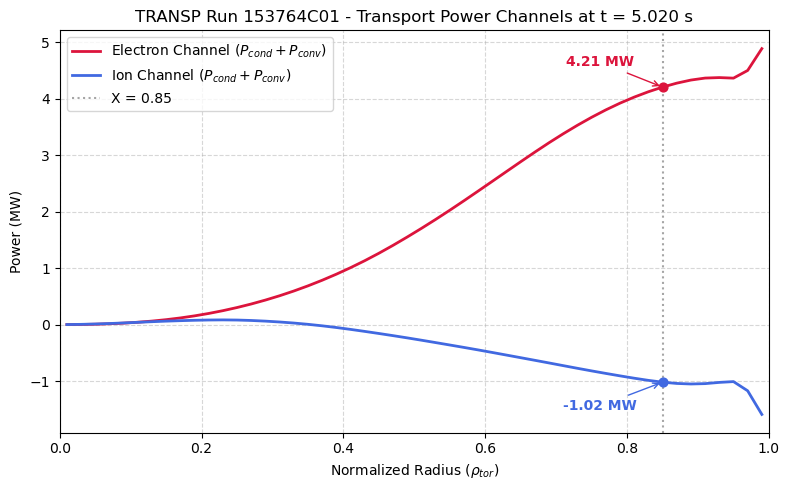

In [4]:
# 5. Plot the Results
plt.figure(figsize=(8, 5))
plt.plot(rhotor_slice, p_total_e_mw, label="Electron Channel ($P_{cond} + P_{conv}$)", color="crimson", lw=2)
plt.plot(rhotor_slice, p_total_i_mw, label="Ion Channel ($P_{cond} + P_{conv}$)", color="royalblue", lw=2)

# Add explicit markers at x = 0.85
# 8. Find the values at the coordinate index closest to 0.85
target_x = 0.85
idx_085 = np.abs(rhotor_slice - target_x).argmin()
actual_x = rhotor_slice[idx_085]
val_e = p_total_e_mw[idx_085]
val_i = p_total_i_mw[idx_085]

plt.scatter([actual_x], [val_e], color="crimson", s=40, zorder=5)
plt.scatter([actual_x], [val_i], color="royalblue", s=40, zorder=5)

# Annotate values with slight offsets to ensure they remain clear and legible
plt.annotate(f"{val_e:.2f} MW", (actual_x, val_e), textcoords="offset points", xytext=(-45, 15),
             ha='center', color="crimson", weight='bold',
             arrowprops=dict(arrowstyle="->", color="crimson", lw=1))

plt.annotate(f"{val_i:.2f} MW", (actual_x, val_i), textcoords="offset points", xytext=(-45, -20),
             ha='center', color="royalblue", weight='bold',
             arrowprops=dict(arrowstyle="->", color="royalblue", lw=1))

# Draw a vertical reference line at the target coordinate
plt.axvline(x=actual_x, color="gray", linestyle=":", alpha=0.7, label=f"X = {actual_x:.2f}")

plt.title(f"TRANSP Run 153764C01 - Transport Power Channels at t = {actual_time:.3f} s")
plt.xlabel(r"Normalized Radius ($\rho_{tor}$)")
plt.ylabel("Power (MW)")
plt.xlim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

## Radial Profiles: $T_e$, $T_i$, $n_e$

TE units: EV                              ,  TI units: EV                              ,  NE units: N/CM**3                         


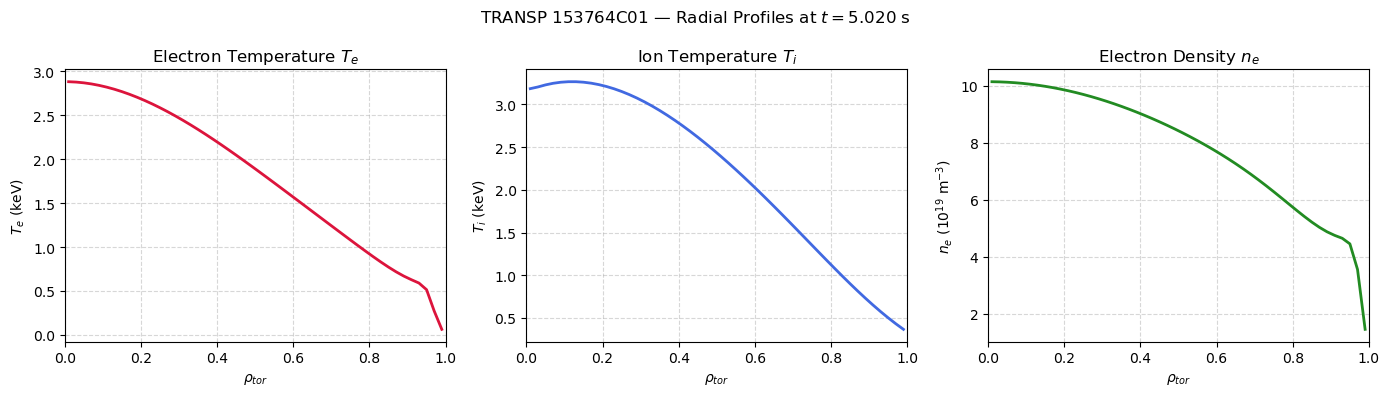

In [5]:
# Extract Te, Ti, ne profiles at the selected time slice
# TRANSP stores temperatures in keV and density in cm^-3
te = nc.variables["TE"][time_idx, :]   # Electron temperature (keV)
ti = nc.variables["TI"][time_idx, :]   # Ion temperature (keV)
ne = nc.variables["NE"][time_idx, :]   # Electron density (cm^-3)

te_units = nc.variables["TE"].units if "units" in nc.variables["TE"].ncattrs() else "?"
ti_units = nc.variables["TI"].units if "units" in nc.variables["TI"].ncattrs() else "?"
ne_units = nc.variables["NE"].units if "units" in nc.variables["NE"].ncattrs() else "?"
print(f"TE units: {te_units},  TI units: {ti_units},  NE units: {ne_units}")

# Convert density to 10^19 m^-3 if stored in cm^-3 (1 cm^-3 = 1e-13 * 1e19 m^-3 -> divide by 1e13)
ne_19 = ne / 1e13   # 10^19 m^-3

# Convert temperatures from eV to keV if needed
def to_keV(arr, units_str):
    if "EV" in units_str.upper() and "KEV" not in units_str.upper():
        return arr / 1e3
    return arr

te_keV = to_keV(te, te_units)
ti_keV = to_keV(ti, ti_units)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Te ---
axes[0].plot(rhotor_slice, te_keV, color="crimson", lw=2)
axes[0].set_xlabel(r"$\rho_{tor}$")
axes[0].set_ylabel(r"$T_e$ (keV)")
axes[0].set_title(r"Electron Temperature $T_e$")
axes[0].set_xlim(0, 1)
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Ti ---
axes[1].plot(rhotor_slice, ti_keV, color="royalblue", lw=2)
axes[1].set_xlabel(r"$\rho_{tor}$")
axes[1].set_ylabel(r"$T_i$ (keV)")
axes[1].set_title(r"Ion Temperature $T_i$")
axes[1].set_xlim(0, 1)
axes[1].grid(True, linestyle="--", alpha=0.5)

# --- ne ---
axes[2].plot(rhotor_slice, ne_19, color="forestgreen", lw=2)
axes[2].set_xlabel(r"$\rho_{tor}$")
axes[2].set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)")
axes[2].set_title(r"Electron Density $n_e$")
axes[2].set_xlim(0, 1)
axes[2].grid(True, linestyle="--", alpha=0.5)

fig.suptitle(f"TRANSP 153764C01 — Radial Profiles at $t = {actual_time:.3f}$ s", fontsize=12)
plt.tight_layout()
plt.show()

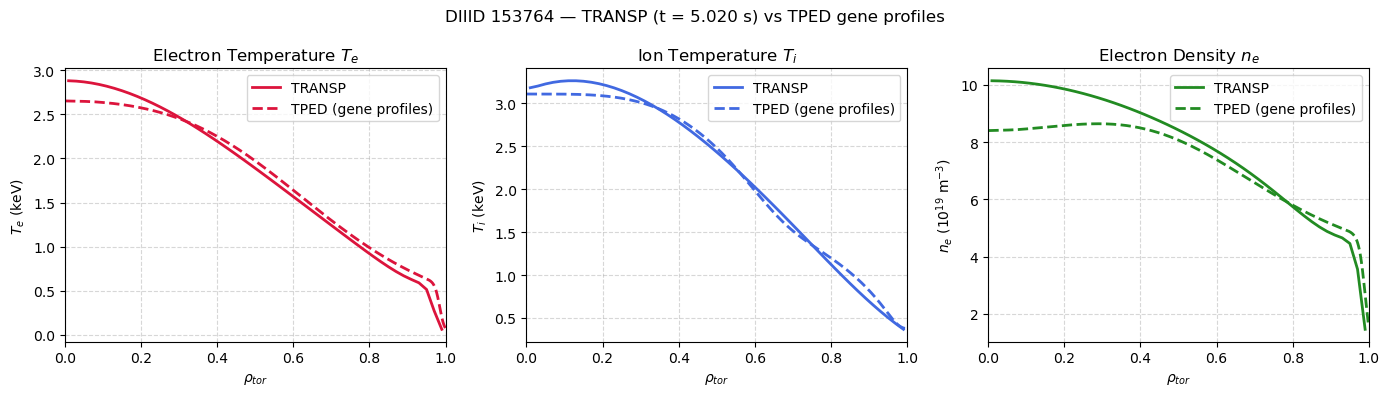

In [6]:
import os
import sys
sys.path.insert(0, os.path.expanduser('~'))

import TPED.projects.profile_tools.src.shot_class as sc

DIIID153764_dict = {
    "shot_id": "DIIID153764",
    "indir": os.path.expanduser("~/DIIID153764"),
    "efit_name": 'g153764.01359',
    "profile_format": 'gene',
    "profname_e": 'profiles_e',
    "profname_i": 'profiles_i',
    "profname_z": 'profiles_z',
    "pfile_name": 'p153764.01359_wnz1',
    "Zi": 1,
    "qz": 6,
}

shot_15 = sc.shot(DIIID153764_dict)

# TPED units: te/ti in eV, ne in m^-3
tped_rhot = shot_15.rhot
tped_te   = shot_15.te / 1e3        # eV -> keV
tped_ti   = shot_15.ti / 1e3        # eV -> keV
tped_ne   = shot_15.ne / 1e19       # m^-3 -> 10^19 m^-3

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Te ---
axes[0].plot(rhotor_slice, te_keV,  color="crimson",    lw=2,   label="TRANSP")
axes[0].plot(tped_rhot,    tped_te, color="crimson",    lw=2,   ls="--", label="TPED (gene profiles)")
axes[0].set_xlabel(r"$\rho_{tor}$")
axes[0].set_ylabel(r"$T_e$ (keV)")
axes[0].set_title(r"Electron Temperature $T_e$")
axes[0].set_xlim(0, 1)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Ti ---
axes[1].plot(rhotor_slice, ti_keV,  color="royalblue",  lw=2,   label="TRANSP")
axes[1].plot(tped_rhot,    tped_ti, color="royalblue",  lw=2,   ls="--", label="TPED (gene profiles)")
axes[1].set_xlabel(r"$\rho_{tor}$")
axes[1].set_ylabel(r"$T_i$ (keV)")
axes[1].set_title(r"Ion Temperature $T_i$")
axes[1].set_xlim(0, 1)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

# --- ne ---
axes[2].plot(rhotor_slice, ne_19,   color="forestgreen", lw=2,   label="TRANSP")
axes[2].plot(tped_rhot,    tped_ne, color="forestgreen", lw=2,   ls="--", label="TPED (gene profiles)")
axes[2].set_xlabel(r"$\rho_{tor}$")
axes[2].set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)")
axes[2].set_title(r"Electron Density $n_e$")
axes[2].set_xlim(0, 1)
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)

fig.suptitle(
    f"DIIID 153764 — TRANSP (t = {actual_time:.3f} s) vs TPED gene profiles",
    fontsize=12,
)
plt.tight_layout()
plt.show()

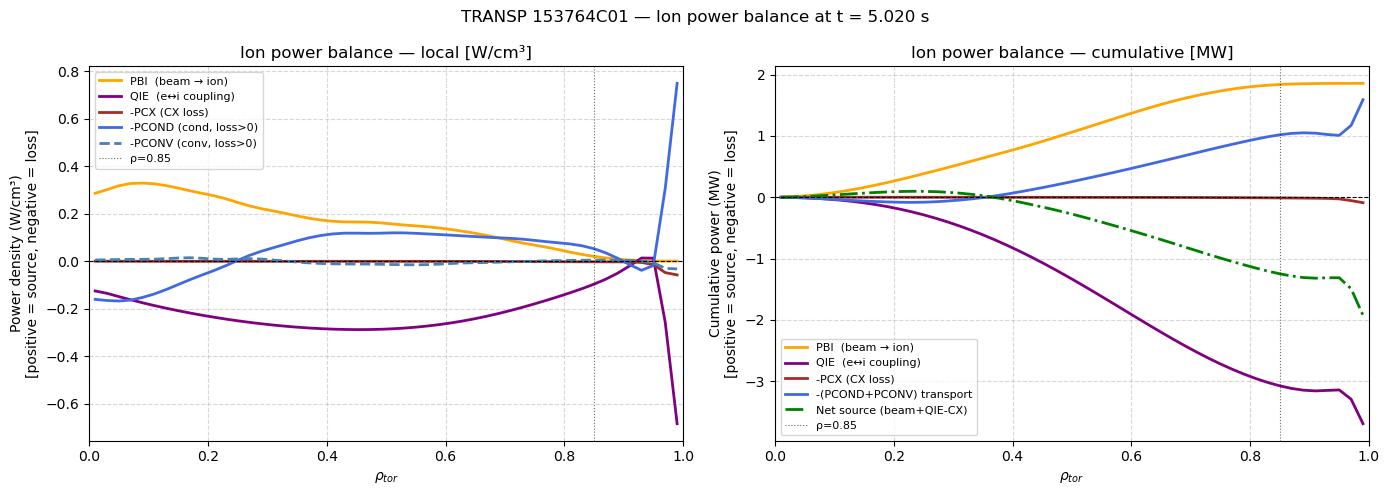


--- Values at rhotor ~ 0.85 [W/cm3] (sources +, losses −) ---
  PBI  (beam→ion)             : +0.02039
  QIE  (e↔i coupling)         : -0.09661
  -PCX  (CX loss)             : -0.00239
  -PCOND (cond, loss>0)       : +0.05279
  -PCONV (conv, loss>0)       : +0.00474
  GAINI (net gain)            : +0.00350

--- Cumulative at rhotor ~ 0.85 [MW] ---
  PBI                      : +1.8393 MW
  QIE                      : -3.0778 MW
  -PCX                     : -0.0113 MW
  -(PCOND+PCONV)           : +1.0195 MW
  Net (beam+QIE-CX)        : -1.2498 MW


In [9]:
# Ion power balance breakdown at the selected time slice
# Sign convention: positive = source/gain for ions, negative = sink/loss
# PCOND and PCONV are defined as losses in TRANSP (positive = outward), so they enter with a minus sign

def get(vname):
    return nc.variables[vname][time_idx, :]

pbi   = get("PBI")    # Beam heating of ions          [W/cm3]  (source, >0)
qie   = get("QIE")    # Ion-electron coupling          [W/cm3]  (>0: e->i, <0: i->e)
pcx   = get("PCX")    # Charge-exchange loss           [W/cm3]  (loss, >0)
pcond = get("PCOND")  # Ion conduction loss            [W/cm3]  (loss when >0)
pconv = get("PCONV")  # Ion convection loss            [W/cm3]  (loss when >0)
pcmpi = get("PCMPI")  # Ion compression                [W/cm3]
gaini = get("GAINI")  # Net ion gain (residual)        [W/cm3]

# Cumulative volume-integrated values [MW]
def cumMW(arr):
    return np.cumsum(arr * dvol_slice) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: local power density profiles ---
# All plotted with physical sign: sources positive, losses negative
ax = axes[0]
ax.plot(rhotor_slice,  pbi,          label="PBI  (beam → ion)",      color="orange",   lw=2)
ax.plot(rhotor_slice,  qie,          label="QIE  (e↔i coupling)",    color="purple",   lw=2)
ax.plot(rhotor_slice, -pcx,          label="-PCX (CX loss)",          color="brown",    lw=2)
ax.plot(rhotor_slice, -pcond,        label="-PCOND (cond, loss>0)",   color="royalblue",lw=2)
ax.plot(rhotor_slice, -pconv,        label="-PCONV (conv, loss>0)",   color="steelblue",lw=2, ls="--")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0.85, color="k", lw=0.8, ls=":", alpha=0.6, label="ρ=0.85")
ax.set_xlabel(r"$\rho_{tor}$")
ax.set_ylabel("Power density (W/cm³)\n[positive = source, negative = loss]")
ax.set_title("Ion power balance — local [W/cm³]")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)

# --- Right: cumulative volume-integrated [MW] ---
ax = axes[1]
ax.plot(rhotor_slice, cumMW( pbi),          label="PBI  (beam → ion)",     color="orange",   lw=2)
ax.plot(rhotor_slice, cumMW( qie),          label="QIE  (e↔i coupling)",   color="purple",   lw=2)
ax.plot(rhotor_slice, cumMW(-pcx),          label="-PCX (CX loss)",         color="brown",    lw=2)
ax.plot(rhotor_slice, cumMW(-pcond-pconv),  label="-(PCOND+PCONV) transport",color="royalblue",lw=2)
ax.plot(rhotor_slice, cumMW(pbi+qie-pcx),  label="Net source (beam+QIE-CX)",color="green",   lw=2, ls="-.")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0.85, color="k", lw=0.8, ls=":", alpha=0.6, label="ρ=0.85")
ax.set_xlabel(r"$\rho_{tor}$")
ax.set_ylabel("Cumulative power (MW)\n[positive = source, negative = loss]")
ax.set_title("Ion power balance — cumulative [MW]")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)

fig.suptitle(f"TRANSP 153764C01 — Ion power balance at t = {actual_time:.3f} s", fontsize=12)
plt.tight_layout()
plt.show()

# Print values at rhotor=0.85
print(f"\n--- Values at rhotor ~ 0.85 [W/cm3] (sources +, losses −) ---")
for name, arr in [("PBI  (beam→ion)",        pbi),
                  ("QIE  (e↔i coupling)",     qie),
                  ("-PCX  (CX loss)",         -pcx),
                  ("-PCOND (cond, loss>0)",   -pcond),
                  ("-PCONV (conv, loss>0)",   -pconv),
                  ("GAINI (net gain)",         gaini)]:
    print(f"  {name:<28}: {arr[idx_085]:+.5f}")

print(f"\n--- Cumulative at rhotor ~ 0.85 [MW] ---")
for name, arr in [("PBI",                    pbi),
                  ("QIE",                    qie),
                  ("-PCX",                   -pcx),
                  ("-(PCOND+PCONV)",         -pcond-pconv),
                  ("Net (beam+QIE-CX)",      pbi+qie-pcx)]:
    print(f"  {name:<25}: {cumMW(arr)[idx_085]:+.4f} MW")

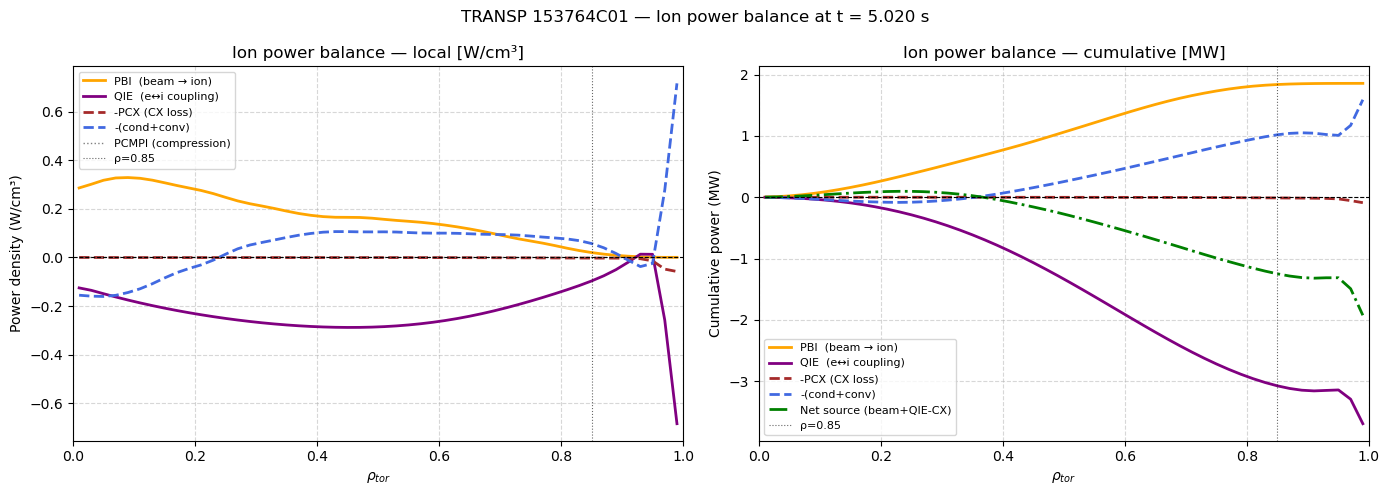


--- Values at rhotor ~ 0.85 [W/cm3] ---
  PBI  (beam→ion)          : +0.02039
  QIE  (e↔i coupling)      : -0.09661
  PCX  (CX loss)           : +0.00239
  PCOND (cond loss)        : -0.05279
  PCONV (conv loss)        : -0.00474
  PCMPI (compression)      : +0.00001
  GAINI (net gain)         : +0.00350

--- Cumulative at rhotor ~ 0.85 [MW] ---
  PBI                      : +1.8393 MW
  QIE                      : -3.0778 MW
  PCX                      : -0.0113 MW
  PCOND+PCONV              : +1.0195 MW
  Net (beam+QIE-CX)        : -1.2498 MW


In [8]:
# Ion power balance breakdown at the selected time slice
# Sign convention in TRANSP: positive = source/gain for ions, negative = sink/loss

def get(vname):
    return nc.variables[vname][time_idx, :]

pbi   = get("PBI")    # Beam heating of ions          [W/cm3]
qie   = get("QIE")    # Ion-electron coupling          [W/cm3]  (>0: e->i, <0: i->e)
pcx   = get("PCX")    # Charge-exchange loss           [W/cm3]
pcond = get("PCOND")  # Ion conduction loss            [W/cm3]
pconv = get("PCONV")  # Ion convection loss            [W/cm3]
pcmpi = get("PCMPI")  # Ion compression                [W/cm3]
gaini = get("GAINI")  # Net ion gain (residual)        [W/cm3]

# Cumulative volume-integrated values [MW]
def cumMW(arr):
    return np.cumsum(arr * dvol_slice) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: local power density profiles ---
ax = axes[0]
ax.plot(rhotor_slice, pbi,           label="PBI  (beam → ion)",     color="orange",   lw=2)
ax.plot(rhotor_slice, qie,           label="QIE  (e↔i coupling)",   color="purple",   lw=2)
ax.plot(rhotor_slice, -pcx,          label="-PCX (CX loss)",         color="brown",    lw=2, ls="--")
ax.plot(rhotor_slice, -(pcond+pconv),label="-(cond+conv)",           color="royalblue",lw=2, ls="--")
ax.plot(rhotor_slice, pcmpi,         label="PCMPI (compression)",    color="gray",     lw=1, ls=":")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0.85, color="k", lw=0.8, ls=":", alpha=0.6, label="ρ=0.85")
ax.set_xlabel(r"$\rho_{tor}$")
ax.set_ylabel("Power density (W/cm³)")
ax.set_title("Ion power balance — local [W/cm³]")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)

# --- Right: cumulative volume-integrated [MW] ---
ax = axes[1]
ax.plot(rhotor_slice, cumMW(pbi),            label="PBI  (beam → ion)",     color="orange",   lw=2)
ax.plot(rhotor_slice, cumMW(qie),            label="QIE  (e↔i coupling)",   color="purple",   lw=2)
ax.plot(rhotor_slice, cumMW(-pcx),           label="-PCX (CX loss)",         color="brown",    lw=2, ls="--")
ax.plot(rhotor_slice, cumMW(-(pcond+pconv)), label="-(cond+conv)",           color="royalblue",lw=2, ls="--")
ax.plot(rhotor_slice, cumMW(pbi+qie-pcx),   label="Net source (beam+QIE-CX)",color="green",   lw=2, ls="-.")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.axvline(0.85, color="k", lw=0.8, ls=":", alpha=0.6, label="ρ=0.85")
ax.set_xlabel(r"$\rho_{tor}$")
ax.set_ylabel("Cumulative power (MW)")
ax.set_title("Ion power balance — cumulative [MW]")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)

fig.suptitle(f"TRANSP 153764C01 — Ion power balance at t = {actual_time:.3f} s", fontsize=12)
plt.tight_layout()
plt.show()

# Print values at rhotor=0.85
print(f"\n--- Values at rhotor ~ 0.85 [W/cm3] ---")
for name, arr in [("PBI  (beam→ion)",     pbi),
                  ("QIE  (e↔i coupling)", qie),
                  ("PCX  (CX loss)",       pcx),
                  ("PCOND (cond loss)",    pcond),
                  ("PCONV (conv loss)",    pconv),
                  ("PCMPI (compression)", pcmpi),
                  ("GAINI (net gain)",    gaini)]:
    print(f"  {name:<25}: {arr[idx_085]:+.5f}")

print(f"\n--- Cumulative at rhotor ~ 0.85 [MW] ---")
for name, arr in [("PBI",        pbi),
                  ("QIE",        qie),
                  ("PCX",        -pcx),
                  ("PCOND+PCONV",-(pcond+pconv)),
                  ("Net (beam+QIE-CX)", pbi+qie-pcx)]:
    print(f"  {name:<25}: {cumMW(arr)[idx_085]:+.4f} MW")

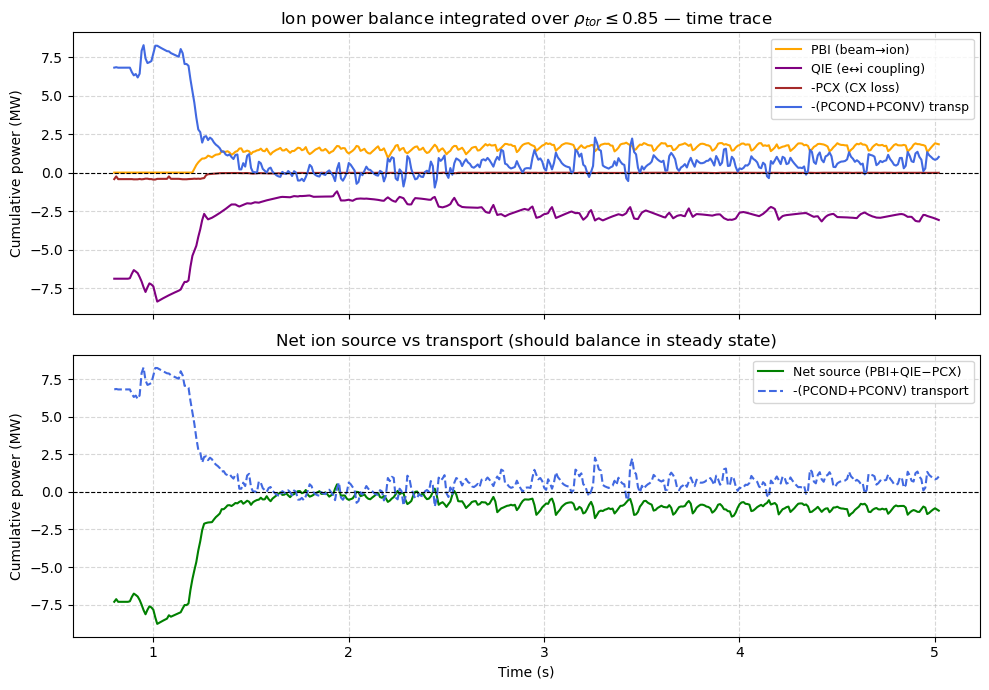

Time range: 0.801 – 5.020 s  (423 steps)
Ion heat flux at rhotor~0.850:
  First time step:  PCOND+PCONV = -6.817 MW
  Last  time step:  PCOND+PCONV = -1.019 MW
  Mean over run:    PCOND+PCONV = -1.229 MW
  Std  over run:                = 2.073 MW


In [10]:
# Time trace of ion power balance terms integrated over 0 → rhotor=0.85
# For each time step, cumsum to the idx_085 index

PCOND_all  = nc.variables["PCOND"][:]   # (ntime, nx)
PCONV_all  = nc.variables["PCONV"][:]
PBI_all    = nc.variables["PBI"][:]
QIE_all    = nc.variables["QIE"][:]
PCX_all    = nc.variables["PCX"][:]
DVOL_all   = nc.variables["DVOL"][:]    # (ntime, nx)
rhotor_all = nc.variables["X"][:]       # (ntime, nx)

# Find rhotor=0.85 index for each time (use mean rhotor for robustness)
mean_rhotor = np.mean(rhotor_all, axis=0)
idx_085_t   = np.argmin(np.abs(mean_rhotor - 0.85))

def cumint_at085(arr_all, dvol_all, idx):
    """Cumulative volume integral from 0 to idx, for all time steps [MW]."""
    return np.sum(arr_all[:, :idx+1] * dvol_all[:, :idx+1], axis=1) / 1e6

Q_cond_conv = cumint_at085(PCOND_all + PCONV_all, DVOL_all, idx_085_t)  # MW, transport loss
Q_pbi       = cumint_at085(PBI_all,  DVOL_all, idx_085_t)
Q_qie       = cumint_at085(QIE_all,  DVOL_all, idx_085_t)
Q_pcx       = cumint_at085(PCX_all,  DVOL_all, idx_085_t)
Q_net_src   = Q_pbi + Q_qie - Q_pcx   # net source: should ≈ Q_cond_conv

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: individual terms
ax = axes[0]
ax.plot(time, Q_pbi,         label="PBI (beam→ion)",      color="orange",   lw=1.5)
ax.plot(time, Q_qie,         label="QIE (e↔i coupling)",  color="purple",   lw=1.5)
ax.plot(time, -Q_pcx,        label="-PCX (CX loss)",       color="brown",    lw=1.5)
ax.plot(time, -Q_cond_conv,  label="-(PCOND+PCONV) transp",color="royalblue",lw=1.5)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_ylabel("Cumulative power (MW)")
ax.set_title(r"Ion power balance integrated over $\rho_{tor} \leq 0.85$ — time trace")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.5)

# Bottom: net source vs transport (should match in steady state)
ax = axes[1]
ax.plot(time,  Q_net_src,    label="Net source (PBI+QIE−PCX)", color="green",     lw=1.5)
ax.plot(time, -Q_cond_conv,  label="-(PCOND+PCONV) transport",  color="royalblue", lw=1.5, ls="--")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Cumulative power (MW)")
ax.set_title("Net ion source vs transport (should balance in steady state)")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Time range: {time[0]:.3f} – {time[-1]:.3f} s  ({len(time)} steps)")
print(f"Ion heat flux at rhotor~{mean_rhotor[idx_085_t]:.3f}:")
print(f"  First time step:  PCOND+PCONV = {Q_cond_conv[0]:+.3f} MW")
print(f"  Last  time step:  PCOND+PCONV = {Q_cond_conv[-1]:+.3f} MW")
print(f"  Mean over run:    PCOND+PCONV = {np.mean(Q_cond_conv):+.3f} MW")
print(f"  Std  over run:                = {np.std(Q_cond_conv):.3f} MW")